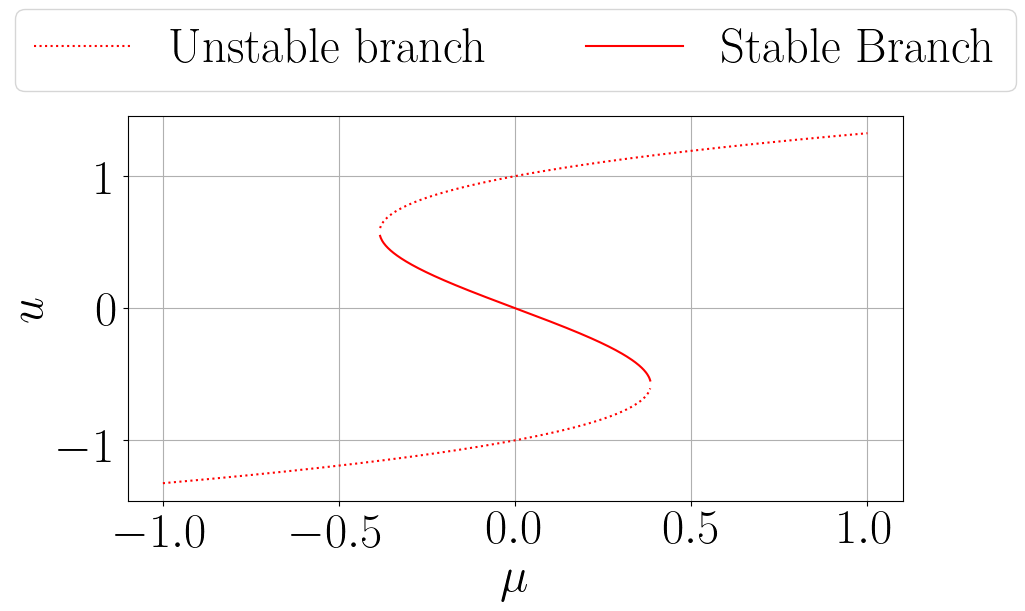

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter range
mu_values = np.linspace(-1, 1, 1000)

plt.rcParams.update({
    'font.size': 35,           # Dimensione generale del font
    'axes.titlesize': 35,      # Titolo dell'asse
    'axes.labelsize': 35,      # Etichette degli assi
    'legend.fontsize': 35,     # Legenda
    'xtick.labelsize': 35,     # Etichette asse x
    'ytick.labelsize': 35      # Etichette asse y
})

plt.rcParams['text.latex.preamble']=r"\usepackage{lmodern}"
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = 30
plt.rcParams['font.family'] = 'lmodern'

# Prepare lists for three branches
mu_low, u_low = [], []
mu_mid, u_mid = [], []
mu_high, u_high = [], []

# Threshold for branch classification (fold points at ±1/√3)
threshold = 1/np.sqrt(3)

for mu in mu_values:
    roots = np.roots([1, 0, -1, -mu])
    real_roots = np.real(roots[np.isreal(roots)])
    # Sort roots for classification
    for u in real_roots:
        if u < -threshold:
            mu_low.append(mu)
            u_low.append(u)
        elif u > threshold:
            mu_high.append(mu)
            u_high.append(u)
        else:
            mu_mid.append(mu)
            u_mid.append(u)

# Plotting
fig, ax = plt.subplots(figsize=(10, 5))  # wider figure
ax.plot(mu_low, u_low, linestyle=':', color="red", label='Unstable branch')
ax.plot(mu_mid, u_mid, linestyle='-', color="red", label='Stable Branch')
ax.plot(mu_high, u_high, linestyle=':', color="red",)
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$u$')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1), ncol=3)
ax.grid(True)
fig.savefig(f"Plots/S_shaped.pdf", bbox_inches="tight")
plt.show()
